<a href="https://colab.research.google.com/github/DataAnalytics808/DASC-522-demo-repository/blob/main/demos/Week_09_F_Checkpointing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##9F Checkpointing

Preamble and Mount google drive

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow

from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

from sklearn import metrics

from keras.callbacks import EarlyStopping

import tensorflow as tf
from tensorflow.keras import regularizers

import os

import csv
from csv import writer

from google.colab import files

# from google.colab import files


Set file and path

In [ ]:
excelFileName = 'batch_output.csv' # to output model HPs and performance

# os.chdir(r"/content/gdrive/MyDrive/522_demo")

print('done')

done


add framework needed for Checkpointing

In [ ]:
!pip3 install pyyaml h5py

Load dataset, Most Data Preparation already completed (not split or normalize)

In [ ]:
# Programmatically download required datasets for checkpointing demo
import urllib.request, os
base_gh = 'https://raw.githubusercontent.com/DataAnalytics808/DASC-522-demo-repository/main/data'
for f in ['Cade_X.csv', 'Cade_y.csv', 'best_model.keras', '347Sum 106FP 241FN 0.837f1.h5']:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f'{base_gh}/{f}', f)

%tensorflow_version 2.x
import tensorflow as tf
from tensorflow import feature_column
from tensorflow.keras import layers

X = pd.read_csv("https://raw.githubusercontent.com/DataAnalytics808/DASC-522-demo-repository/main/data/Cade_X.csv")
y = pd.read_csv("https://raw.githubusercontent.com/DataAnalytics808/DASC-522-demo-repository/main/data/Cade_y.csv")

X.pop('year')  # delete year
print('done')

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
done


Split data

In [ ]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

from sklearn.model_selection import GridSearchCV
import keras
from keras.models import Sequential
from keras.layers import Dense
# from keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras.optimizers import SGD

print('Dataset X\n',X)
print('Dataset y\n',y,'\n')

my_seed=44

# split into train/test and validation (holdout) sets
X_splitAgain, X_val, y_splitAgain, y_val = train_test_split(X, y,
                                                            test_size=0.15,
                                                            random_state=44,
                                                            stratify=y)   # 1st split - remove 15% for validation (holdout)

X_train, X_test, y_train, y_test = train_test_split(X_splitAgain, y_splitAgain,
                                                    test_size=0.1763,
                                                    random_state=my_seed,
                                                    stratify=y_splitAgain)   # 2nd split

print('Train set shape\n',X_train.shape, y_train.shape)
print('Test set shape\n',X_test.shape, y_test.shape)
print('Val set shape\n',X_val.shape, y_val.shape)
print(' ')

print(np.mean(y_train))
print(np.mean(y_test))
print(np.mean(y_val))

Dataset X
        centx  centy  month  fews_ha  ndvi_mean  ndvi_anom  rain_mean  rain_anom  et_mean  et_anom  acled_count  acled_fatalities  p_staple_food    area  cropland_pct       pop  ruggedness_mean  pasture_pct  log_pop  log_ruggedness
0       65.7   31.0      4      0.0        0.1       98.5        2.9        0.5      4.7      2.1            0                 0            1.0 54174.5           1.4 1379956.0         101047.2         16.2     14.1            11.5
1       65.7   31.0      7      0.0        0.1      104.6        0.4       -0.1      0.3     -0.0            0                 0            1.0 54174.5           1.4 1379956.0         101047.2         16.2     14.1            11.5
2       65.7   31.0     10      0.0        0.1      104.1        0.5       -0.1      0.6      0.2            0                 0            1.2 54174.5           1.4 1379956.0         101047.2         16.2     14.1            11.5
3       65.7   31.0      1      0.0        0.1       97.3        

Train the normalizer

In [ ]:
from tensorflow.keras.layers import Normalization
X_normalizer = Normalization(input_shape=[len(X.columns),])
X_normalizer.adapt(np.array(X))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Main training function

In [ ]:
def build_train_save(my_count, if_graphs=0):

  # (re)define checkpointing callback so that state is cleared
  mc = tf.keras.callbacks.ModelCheckpoint('best_model.keras',
                                          monitor='val_accuracy',
                                          mode='max',
                                          verbose=1,
                                          save_best_only=True)

  print("{}neur {}lay {}LR {}batch".format(num_neurons,num_layers,my_learning_rate,my_batch_size))

  # create model ---------------
  model_final = Sequential([X_normalizer])

  model_final.add(Dense(num_neurons,
                        input_dim=len(X_train.columns),
                        activation='relu',
                        kernel_regularizer=regularizers.l2(my_l2_regularization)))

  num_layers_temp = num_layers
  if num_layers_temp > 0:     # add optional hidden layers

    while num_layers_temp > 0:
      model_final.add(Dense(num_neurons, activation='relu',
                        kernel_regularizer=regularizers.l2(my_l2_regularization)))
      num_layers_temp=num_layers_temp-1

  model_final.add(Dense(1, activation='sigmoid'))

  # Compile model -------------------


  opt = tensorflow.keras.optimizers.Adam(learning_rate=my_learning_rate,
                              epsilon=my_epsilon,
                              beta_1=0.9,
                              beta_2=0.999,
                              amsgrad=False)
  # opt = keras.optimizers.SGD(learning_rate=my_learning_rate,
  #                             momentum=my_momentum)
  METRICS = [tf.keras.metrics.BinaryAccuracy(name='accuracy', threshold=0.5)]

  model_final.compile(loss='binary_crossentropy',
                      optimizer=opt,
                      metrics=METRICS)

  # Train the model on the training set, test on the test set ----------------
  history = model_final.fit(X_train,
                            y_train,
                            epochs=my_epochs,
                            batch_size=my_batch_size,
                            callbacks=[mc],
                            verbose=0,
                            validation_data=(X_test, y_test))

  # the final model is either from the first iteration, or checkpointed. Retain as "loaded_model"
  if os.path.isfile('best_model.h5') == False:
    print('***********no model - save current')
    loaded_model = model_final
  else:
    # load best model,
    loaded_model = tf.keras.models.load_model('best_model.h5')



  # ---------- Gather metrics
  auc_test, accuracy_test, precision_test, recall_test, f1_test, FN_test, FP_test = eval_classif_model(loaded_model, X_test, y_test)
  auc_all, accuracy_all, precision_all, recall_all, f1_all, FN_all, FP_all        = eval_classif_model(loaded_model, X,      y)
  auc_val, accuracy_val, precision_val, recall_val, f1_val, FN_val, FP_val        = eval_classif_model(loaded_model, X_val,  y_val)

    # ---------- create filename from *test data*, save best model

  new_filename = "{}Sum {}FP {}FN 0.{}f1.h5".format(FP_test+FN_test, FP_test, FN_test, round(f1_test*1000))

  if os.path.isfile('best_model.h5') == False:
    loaded_model.save(new_filename)
  else:
    os.rename('best_model.h5',new_filename)
    # also save model at last iteration (with HP metadata)

  # write hyperparameter metadata and model performance to csv file
  d=[my_count,
     num_neurons,
     num_layers,
     my_l2_regularization,
     my_learning_rate,
     my_batch_size,
     my_epsilon,
     my_epochs,    # ------------end of HPs
     FP_all+FN_all,
     FP_all,
     FN_all,
     round(auc_all*100),
     round(accuracy_all*1000),
     precision_all,
     recall_all,
     f1_all,   # ---------------end of _all
     FP_test+FN_test,
     FP_test,
     FN_test,
     round(auc_test*100),
     round(accuracy_test*1000),
     precision_test,
     recall_test,
     f1_test,   # ---------------end of _test
     FP_val+FN_val,
     FP_val,
     FN_val,
     round(auc_val*100),
     round(accuracy_val*1000),
     precision_val,
     recall_val,
     f1_val]    # ---------------end of _val

  with open(excelFileName, 'a+', newline='') as write_obj:
        # Create a writer object from csv module
        csv_writer = writer(write_obj)
        # Add contents of list as last row in the csv file
        csv_writer.writerow(d)

  if if_graphs:
    evaluate_model(loaded_model)

    # plot history
    plt.figure()
    plt.xlabel("Epoch Threshold", fontsize = 15)
    plt.ylabel("Value", fontsize = 15)
    plt.plot(history.history['accuracy'], label = 'accuracy')
    plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
    plt.xticks(fontsize = 15)
    plt.yticks(fontsize = 15)
    plt.ylim(0.9, 1.0)
    plt.legend()


print('done')



done


Classification Evaluation routine - used by main function to gather metrics

In [ ]:
def eval_classif_model(model, X_input, y_input, thresh=0.5):

  # AUC
  y_pred = model.predict(X_input)
  fpr, tpr, thresholds = roc_curve(y_input, y_pred)
  AUC_from_fn = auc(fpr, tpr)

  # accuracy, precision, recall, F1
  y_pred = np.round(model.predict(X_input))
  report = classification_report(y_input, y_pred, output_dict=True )

  accuracy_from_fn = report['accuracy']
  precision_from_fn =  report['macro avg']['precision']
  recall_from_fn = report['macro avg']['recall']
  f1_from_fn = report['macro avg']['f1-score']

  # FN, FP
  cm = confusion_matrix(y_input, y_pred)
  FP_from_fn = cm[0,1]
  FN_from_fn = cm[1,0]

  return [AUC_from_fn, accuracy_from_fn, precision_from_fn, recall_from_fn, f1_from_fn, FN_from_fn, FP_from_fn]

print('done')

done


Define callbacks

In [ ]:
# The following variables are the hyperparameters.
# my_learning_rate = 0.0001
# # my_epochs = 1500 # define at top
# my_batch_size = 1024
# my_momentum=0.3
# num_neurons = 8
# num_layers = 1
# my_l2_regularization = 0.05

# define checkpointing callback
mc = tf.keras.callbacks.ModelCheckpoint('best_model.keras',
                                        monitor='val_accuracy',
                                        mode='max',
                                        verbose=1,
                                        save_best_only=True)


# simple early stopping (not used)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=400, min_delta=0.0001)

print('done')

done


Model evaluation functions

In [ ]:
def plot_confusion_matrix(data, labels):
    plt.figure(figsize=(6,4))
    plt.title('Confusion Matrix - NN Model',fontsize=12)
    sns.set(font_scale=1)
    ax = sns.heatmap(data, annot=True, cmap='Blues', fmt='g')
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set(ylabel="True Label", xlabel="Predicted Label")

print('done')

done


In [ ]:
def evaluate_model(model):

  # plot results

  y_pred = model.predict(X_test)
  fpr, tpr, thresholds = roc_curve(y_test, y_pred)
  auc_keras = auc(fpr, tpr)

  plt.figure()
  plt.plot(fpr, tpr, label='Keras NN (AUC = %0.2f)' % auc_keras)
  plt.plot([0, 1], [0, 1],'r--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic - NN Model')
  plt.legend(loc="lower right")
  plt.show()

  y_pred = np.round(model.predict(X_test))    # confusion matrix needs binary output

  cm = confusion_matrix(y_test, y_pred)
  print(cm)

  labels = ['non-user','user']
  plot_confusion_matrix(cm, labels)
  plt.show()

  print('\n--NN Classification Report--\n',classification_report(y_test, y_pred,target_names=('non-user','user')))

print('done')

done


Finally, multidimensional hyperparameter sweep!

In [ ]:
# define loop params
start=1
end=3000
my_epochs = 700

counter=1  # don't change this to resume runs - change "start" above

# The code below takes hours to run, so it is commented out

# for num_layers in [0, 1, 2, 3]:
#   for my_epsilon in [0.0001]:
#     for num_neurons in [50, 100, 150, 200, 250]:
#       for my_batch_size in [128, 256, 512, 1024]:
#         for my_l2_regularization in [0, 0.0001, 0.0005, 0.001, 0.002]:
#           for my_learning_rate in [0.0005, 0.001, 0.002, 0.004, 0.006]:

#             if (counter>=start and counter<end):
#                 print(counter)
#                 build_train_save(counter)

#             counter=counter+1




Four-network test

In [ ]:
# smaller version of the loop above
start=1
end=3000
my_epochs = 100

counter=1  # don't change this to resume runs - change "start" above

for num_layers in [1, 2]:
  for my_epsilon in [0.0001]:
    for num_neurons in [150, 200]:
      for my_batch_size in [1024]:
        for my_l2_regularization in [0.0001]:
          for my_learning_rate in [0.002]:

            if (counter>=start and counter<end):
                print(counter)
                build_train_save(counter)

            counter=counter+1

1
150neur 1lay 0.002LR 1024batch


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 1: val_accuracy improved from None to 0.86749, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras

Epoch 2: val_accuracy improved from 0.86749 to 0.87409, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras

Epoch 3: val_accuracy improved from 0.87409 to 0.87750, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras

Epoch 4: val_accuracy improved from 0.87750 to 0.88274, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras

Epoch 5: val_accuracy improved from 0.88274 to 0.88661, saving model to best_model.keras

Epoch 5: finished saving model to best_model.keras

Epoch 6: val_accuracy improved from 0.88661 to 0.88934, saving model to best_model.keras

Epoch 6: finished saving model to best_model.keras

Epoch 7: val_accuracy improved from 0.88934 to 0.89253, saving model to best_model.keras

Epoch 7: finished saving model to best_model.keras

Epoch 8:

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2
200neur 1lay 0.002LR 1024batch

Epoch 1: val_accuracy improved from None to 0.86817, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras

Epoch 2: val_accuracy improved from 0.86817 to 0.87363, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras

Epoch 3: val_accuracy improved from 0.87363 to 0.87705, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras

Epoch 4: val_accuracy improved from 0.87705 to 0.88206, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras

Epoch 5: val_accuracy improved from 0.88206 to 0.88661, saving model to best_model.keras

Epoch 5: finished saving model to best_model.keras

Epoch 6: val_accuracy improved from 0.88661 to 0.89003, saving model to best_model.keras

Epoch 6: finished saving model to best_model.keras

Epoch 7: val_accuracy improved from 0.89003 to 0.89572, saving model to best_model.keras

Epoch 7: finished saving mo

...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 1: val_accuracy improved from None to 0.86498, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras

Epoch 2: val_accuracy improved from 0.86498 to 0.87250, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras

Epoch 3: val_accuracy improved from 0.87250 to 0.87887, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras

Epoch 4: val_accuracy improved from 0.87887 to 0.88502, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras

Epoch 5: val_accuracy improved from 0.88502 to 0.89048, saving model to best_model.keras

Epoch 5: finished saving model to best_model.keras

Epoch 6: val_accuracy improved from 0.89048 to 0.89800, saving model to best_model.keras

Epoch 6: finished saving model to best_model.keras

Epoch 7: val_accuracy improved from 0.89800 to 0.90027, saving model to best_model.keras

Epoch 7: finished saving model to best_model.keras

Epoch 8:

4
200neur 2lay 0.002LR 1024batch


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 1: val_accuracy improved from None to 0.86703, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras

Epoch 2: val_accuracy improved from 0.86703 to 0.87500, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras

Epoch 3: val_accuracy improved from 0.87500 to 0.88024, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras

Epoch 4: val_accuracy improved from 0.88024 to 0.88889, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras

Epoch 5: val_accuracy improved from 0.88889 to 0.89754, saving model to best_model.keras

Epoch 5: finished saving model to best_model.keras

Epoch 6: val_accuracy improved from 0.89754 to 0.89982, saving model to best_model.keras

Epoch 6: finished saving model to best_model.keras

Epoch 7: val_accuracy improved from 0.89982 to 0.90027, saving model to best_model.keras

Epoch 7: finished saving model to best_model.keras

Epoch 8:

Evaluate loaded model

138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


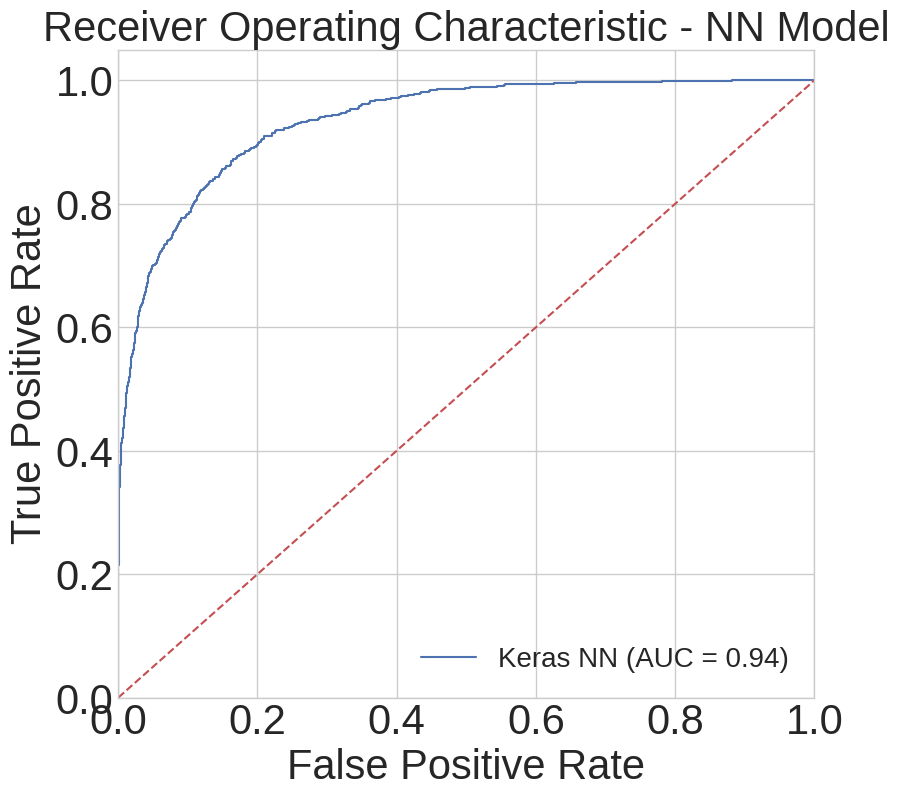

138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[3552  153]
 [ 228  459]]


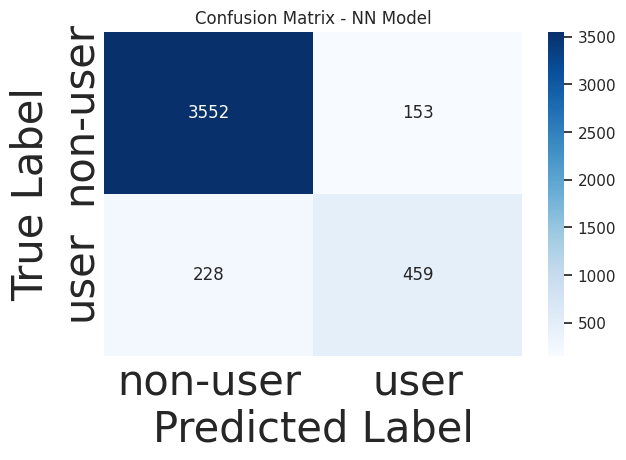


--NN Classification Report--
               precision    recall  f1-score   support

    non-user       0.94      0.96      0.95      3705
        user       0.75      0.67      0.71       687

    accuracy                           0.91      4392
   macro avg       0.84      0.81      0.83      4392
weighted avg       0.91      0.91      0.91      4392

916/916 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9474 - loss: 0.1723

 Final Accuracy: 94.74


In [ ]:
file=('347Sum 106FP 241FN 0.837f1.h5')
loaded_model = tf.keras.models.load_model(file)
evaluate_model(loaded_model)

_, accuracy = loaded_model.evaluate(X, y)
print('\n Final Accuracy: %.2f' % (accuracy*100))

# text version of output
# AUC, accuracy, precision, recall, f1, FN, FP = eval_classif_model(loaded_model, X_test, y_test)

# print(AUC, accuracy, precision, recall, f1, FN, FP)